# Life Expectancy & GDP Analysis
### World Health Organization & World Bank Data (2000–2015)

## Introduction
In this analysis we explore the relationship between GDP and life expectancy 
across six countries over 15 years. 

**Research Questions:**
- Is there a correlation between GDP and life expectancy?
- How have both metrics changed over time?
- Which countries show the strongest relationship?

**Countries:** Chile, China, Germany, Mexico, United States, Zimbabwe

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 150


## 1. Load and Inspecting Data

In [2]:
df = pd.read_csv('all_data.csv')
 
print(df.shape)
print(df.dtypes)
df.head(10)


(96, 4)
Country                              object
Year                                  int64
Life expectancy at birth (years)    float64
GDP                                 float64
dtype: object


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10
5,Chile,2005,78.4,1.229650e+11
6,Chile,2006,78.9,1.547880e+11
7,Chile,2007,78.9,1.736060e+11
8,Chile,2008,79.6,1.796380e+11
9,Chile,2009,79.3,1.723890e+11


## 2. Cleaning Data

In [3]:
print(df.isnull().sum())
 
df.columns = df.columns.str.strip()
df.rename(columns={
    'Life expectancy at birth (years)': 'life_expectancy',
    'GDP': 'gdp'
}, inplace=True)
 
print(df['Country'].unique())
print(df['Year'].min(), df['Year'].max())


Country                             0
Year                                0
Life expectancy at birth (years)    0
GDP                                 0
dtype: int64
['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']
2000 2015


## 3. Summary Statistics

In [4]:
# Overall summary
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"Years covered: {df['Year'].min()} - {df['Year'].max()}")
print(f"Countries: {list(df['Country'].unique())}")
print()

# Summary stats
df[['life_expectancy', 'gdp']].describe().round(2)

=== Dataset Overview ===
Shape: (96, 4)
Years covered: 2000 - 2015
Countries: ['Chile', 'China', 'Germany', 'Mexico', 'United States of America', 'Zimbabwe']



,life_expectancy,gdp
count,96.00,9.600000e+01
mean,72.79,3.880499e+12
std,10.67,5.197561e+12
min,44.30,4.415703e+09
25%,74.47,1.733018e+11
50%,76.75,1.280220e+12
75%,78.90,4.067510e+12
max,81.00,1.810000e+13


### Observations made:
- The average life expectancy across all countries and years is 73 year (to the nearest year)
- GDP ranges between 4.4 billion and 18 trillion which can suggest major economic disparity between the nations analysed over the years
- There are no null values, so no additions had to be made to the dataset

## 4. Visualisations

### 4.1 Life Expectancy Over Time

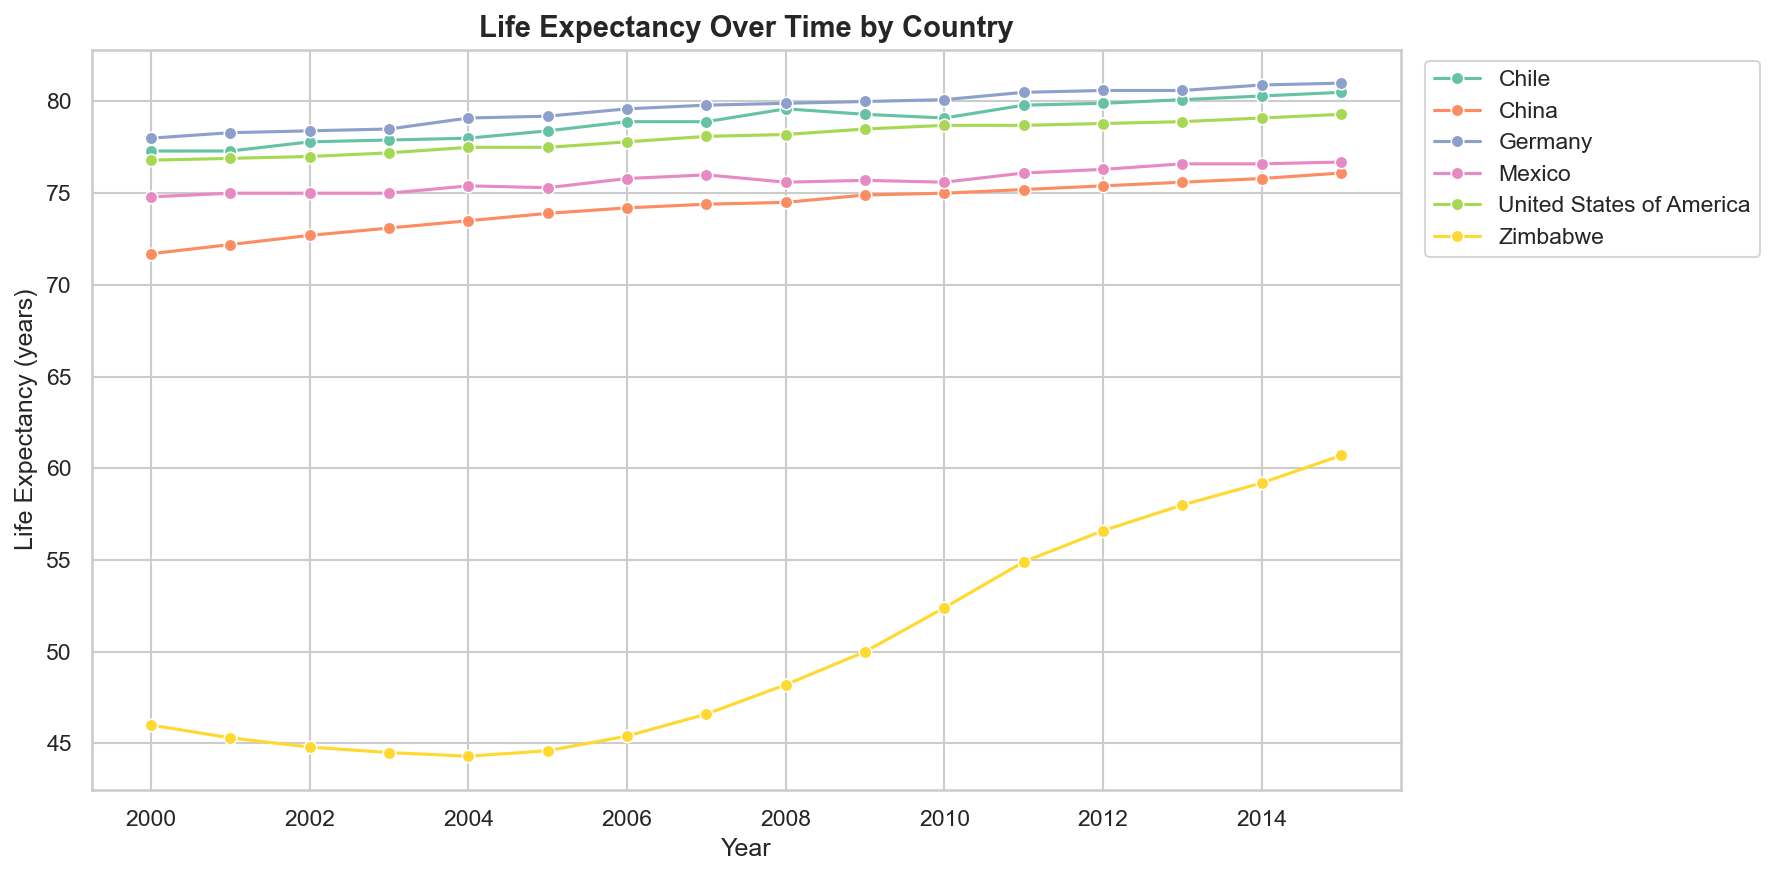

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='life_expectancy',
             hue='Country', marker='o', ax=ax)
ax.set_title('Life Expectancy Over Time by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/life_expectancy_over_time.png', bbox_inches='tight')
plt.show()

### Insights Found:
- In **all 6 analysed nations** life expectancy has improved between 2000 and 2015
- Zimbabwe showed the greatest improvement from the years 2005 to 2015 after a slight decline from 2000
- The remaining 5 nations already started highly and have maintained slow improvement with Germany and Chile showing the highest life expectancies of the 6 nations

### 4.2 GDP Over Time

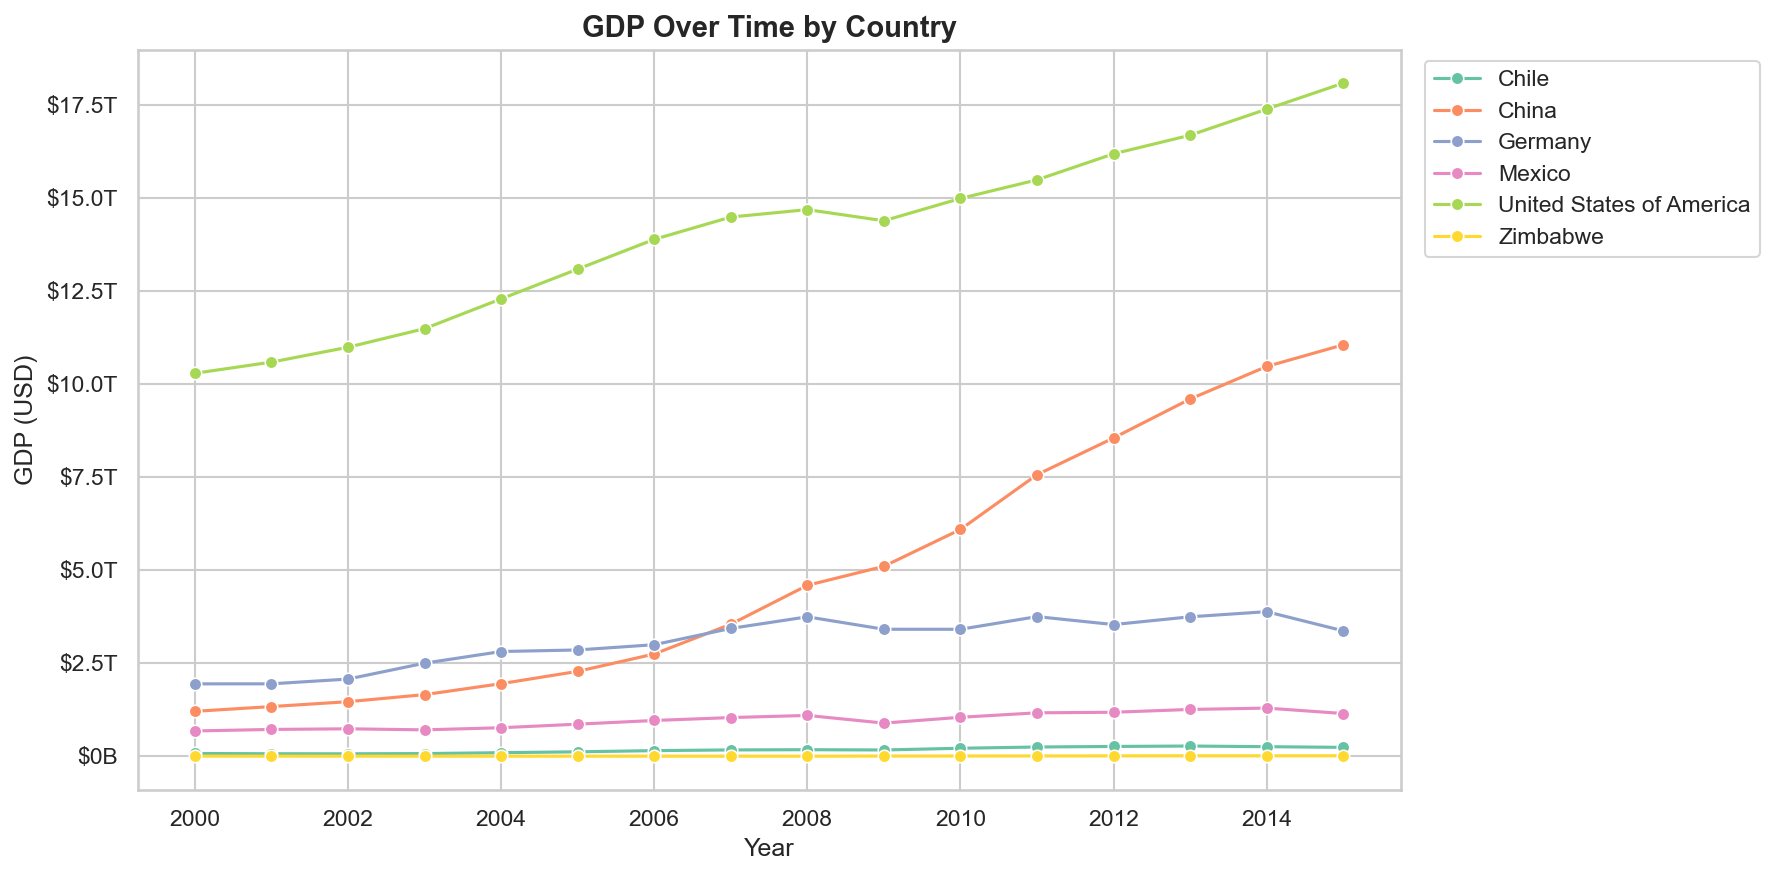

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='gdp',
             hue='Country', marker='o', ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'${x/1e12:.1f}T' if x >= 1e12 else f'${x/1e9:.0f}B'
))
ax.set_title('GDP Over Time by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('GDP (USD)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/gdp_over_time.png', bbox_inches='tight')
plt.show()

### Insights Made
- GPD has increased in all 6 countries over the analysed period
- The USA and China show far greater GDP values compared to the others which China showing the most improved GDP value
- Zimbabwe and Chile have relatively low GDPs
- The financial 'Panic of 2008' is noticeable in a majority of the nations observed with dips in GDP between 2008 and 2009. The only exception being China where GDP continued improving

### 4.3 GDP vs Life Expectancy

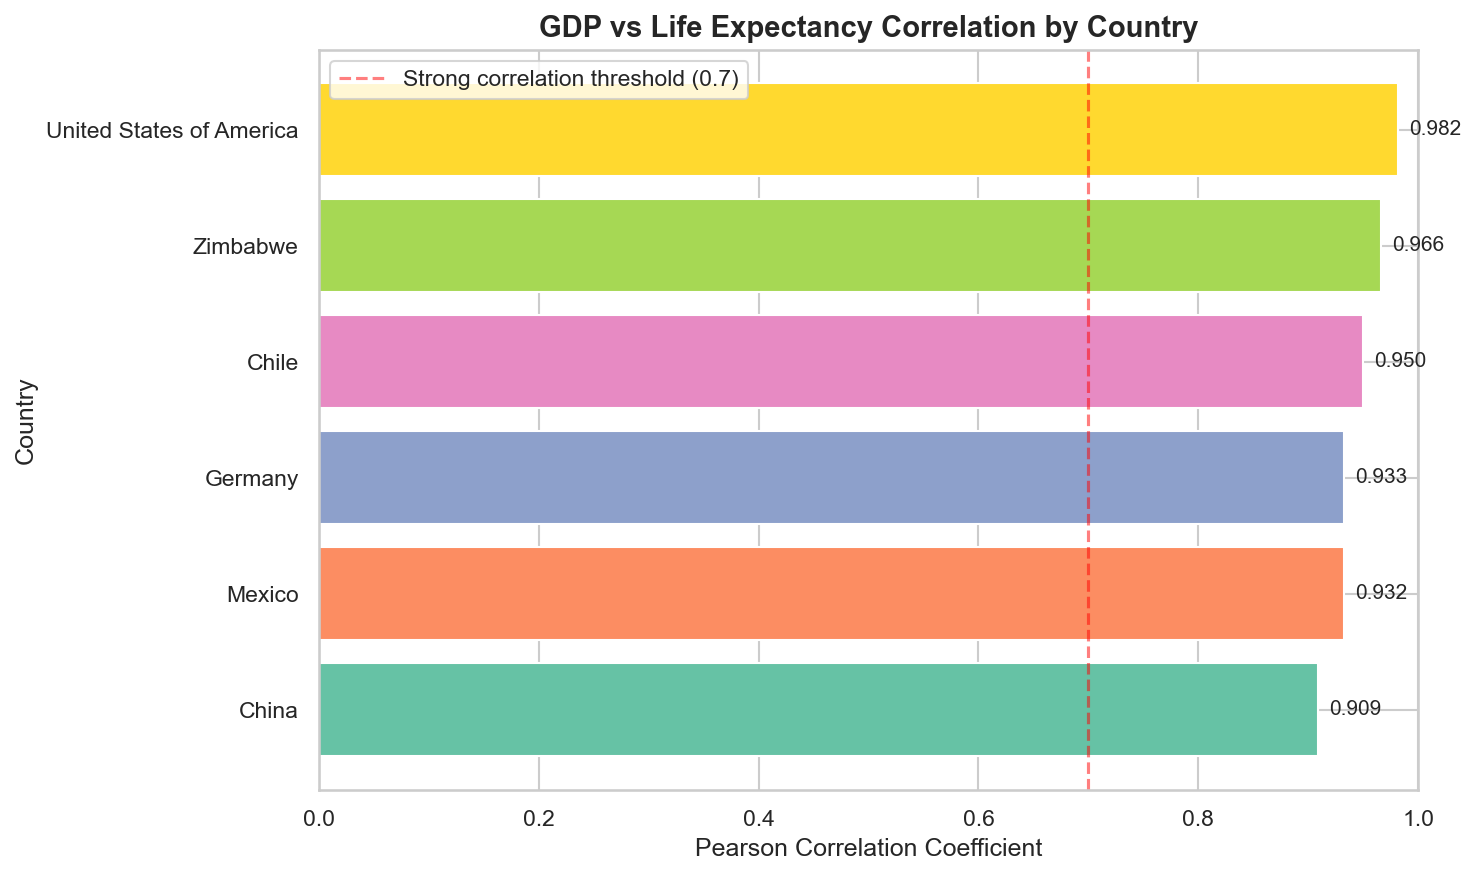

In [ ]:
# Calculate correlation per country
country_corr = {}
for country in df['Country'].unique():
    subset = df[df['Country'] == country]
    country_corr[country] = subset['gdp'].corr(subset['life_expectancy'])

corr_df = pd.Series(country_corr).sort_values()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_df.index, corr_df.values, 
               color=sns.color_palette('Set2', len(corr_df)))
ax.set_xlim(0, 1)
ax.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Strong correlation threshold (0.7)')
ax.set_title('GDP vs Life Expectancy Correlation by Country', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Country')
ax.legend()

# Labelling
for bar, val in zip(bars, corr_df.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('images/correlation_by_country.png', bbox_inches='tight')
plt.show()

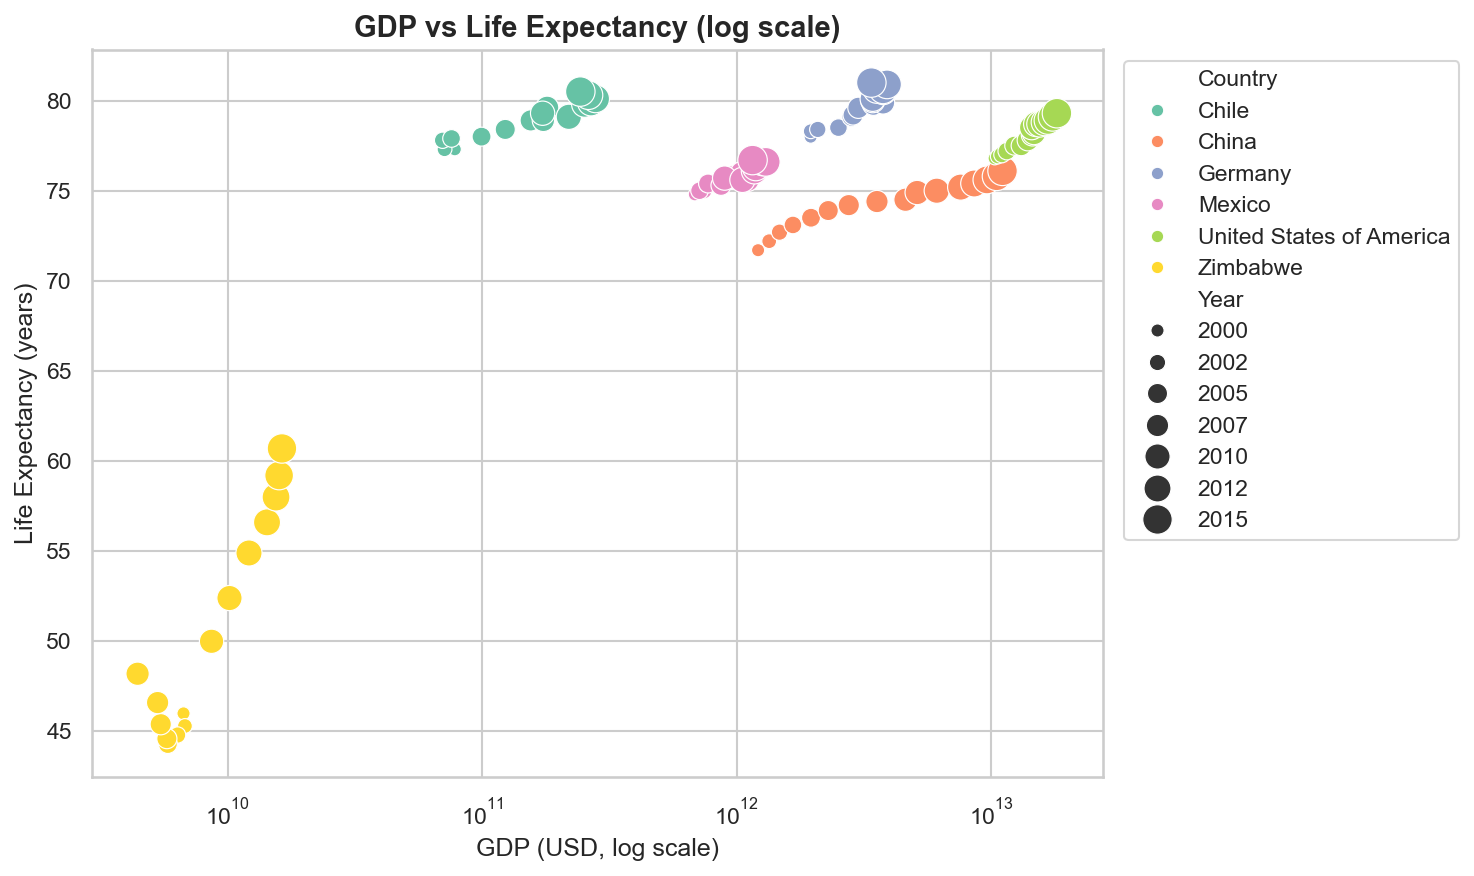

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='gdp', y='life_expectancy',
                hue='Country', size='Year', sizes=(40, 200), ax=ax)
ax.set_xscale('log')
ax.set_title('GDP vs Life Expectancy (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('GDP (USD, log scale)')
ax.set_ylabel('Life Expectancy (years)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('images/gdp_vs_life_expectancy.png', bbox_inches='tight')
plt.show()

### 4.4 Average Life Expectancy

=== Average Life Expectancy by Country ===
Country
Zimbabwe                    50.09
China                       74.26
Mexico                      75.72
United States of America    78.06
Chile                       78.94
Germany                     79.66
Name: life_expectancy, dtype: float64



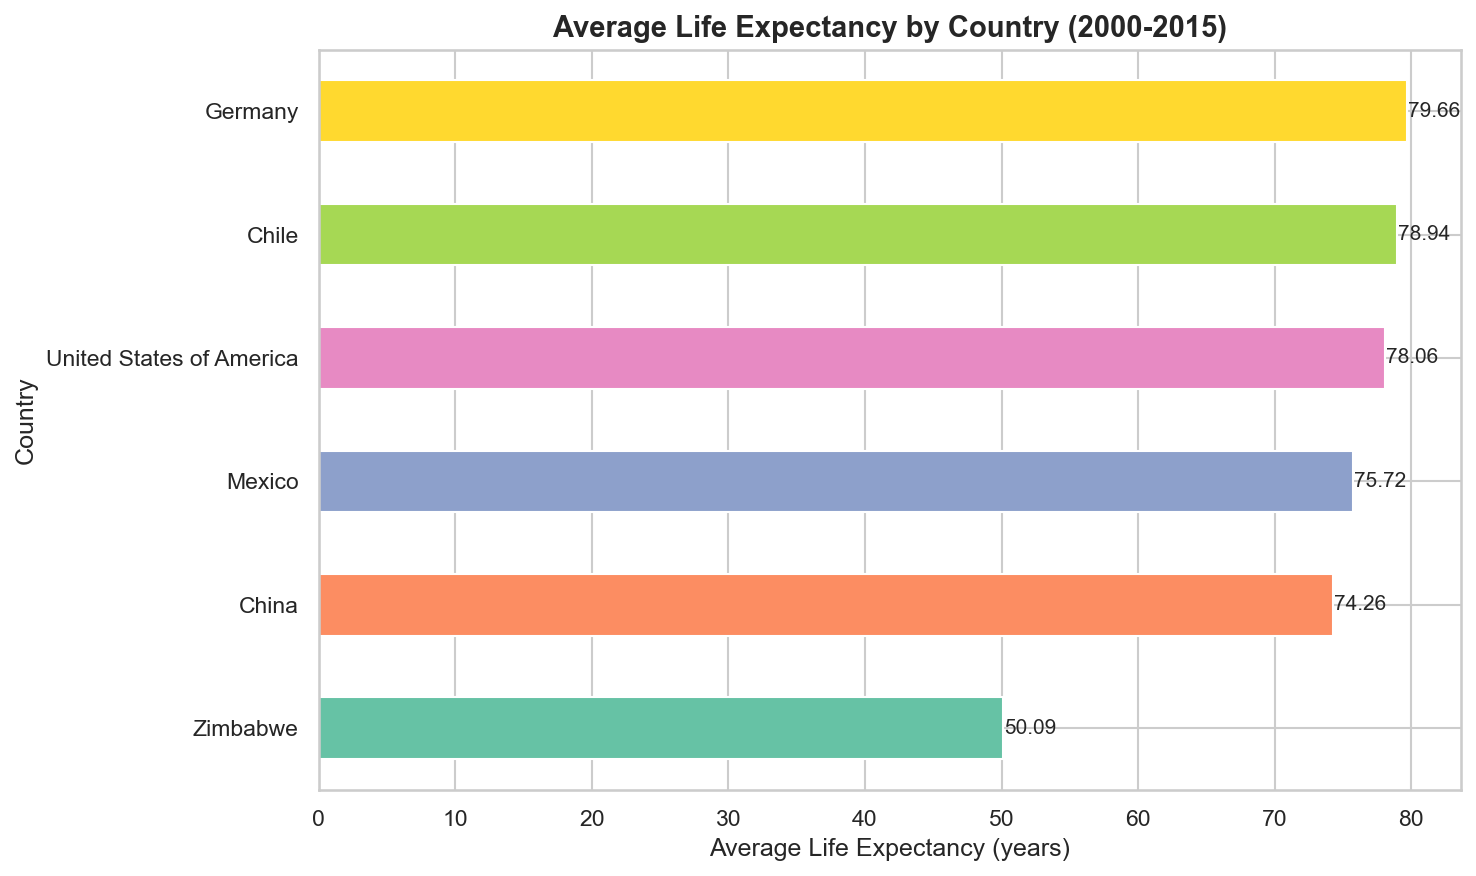

In [13]:
# Calculate averages
avg_le = df.groupby('Country')['life_expectancy'].mean().round(2).sort_values()
print("=== Average Life Expectancy by Country ===")
print(avg_le)
print()

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
avg_le.plot(kind='barh', ax=ax, color=sns.color_palette('Set2', len(avg_le)))
ax.set_title('Average Life Expectancy by Country (2000-2015)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Average Life Expectancy (years)')
ax.set_ylabel('Country')
for i, v in enumerate(avg_le):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('images/average_life_expectancy.png', bbox_inches='tight')
plt.show()

### 4.5 Distribution of Life Expectancy

C:\Users\ashet\AppData\Local\Temp\ipykernel_21540\917356471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Country', y='life_expectancy',
C:\Users\ashet\AppData\Local\Temp\ipykernel_21540\917356471.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')


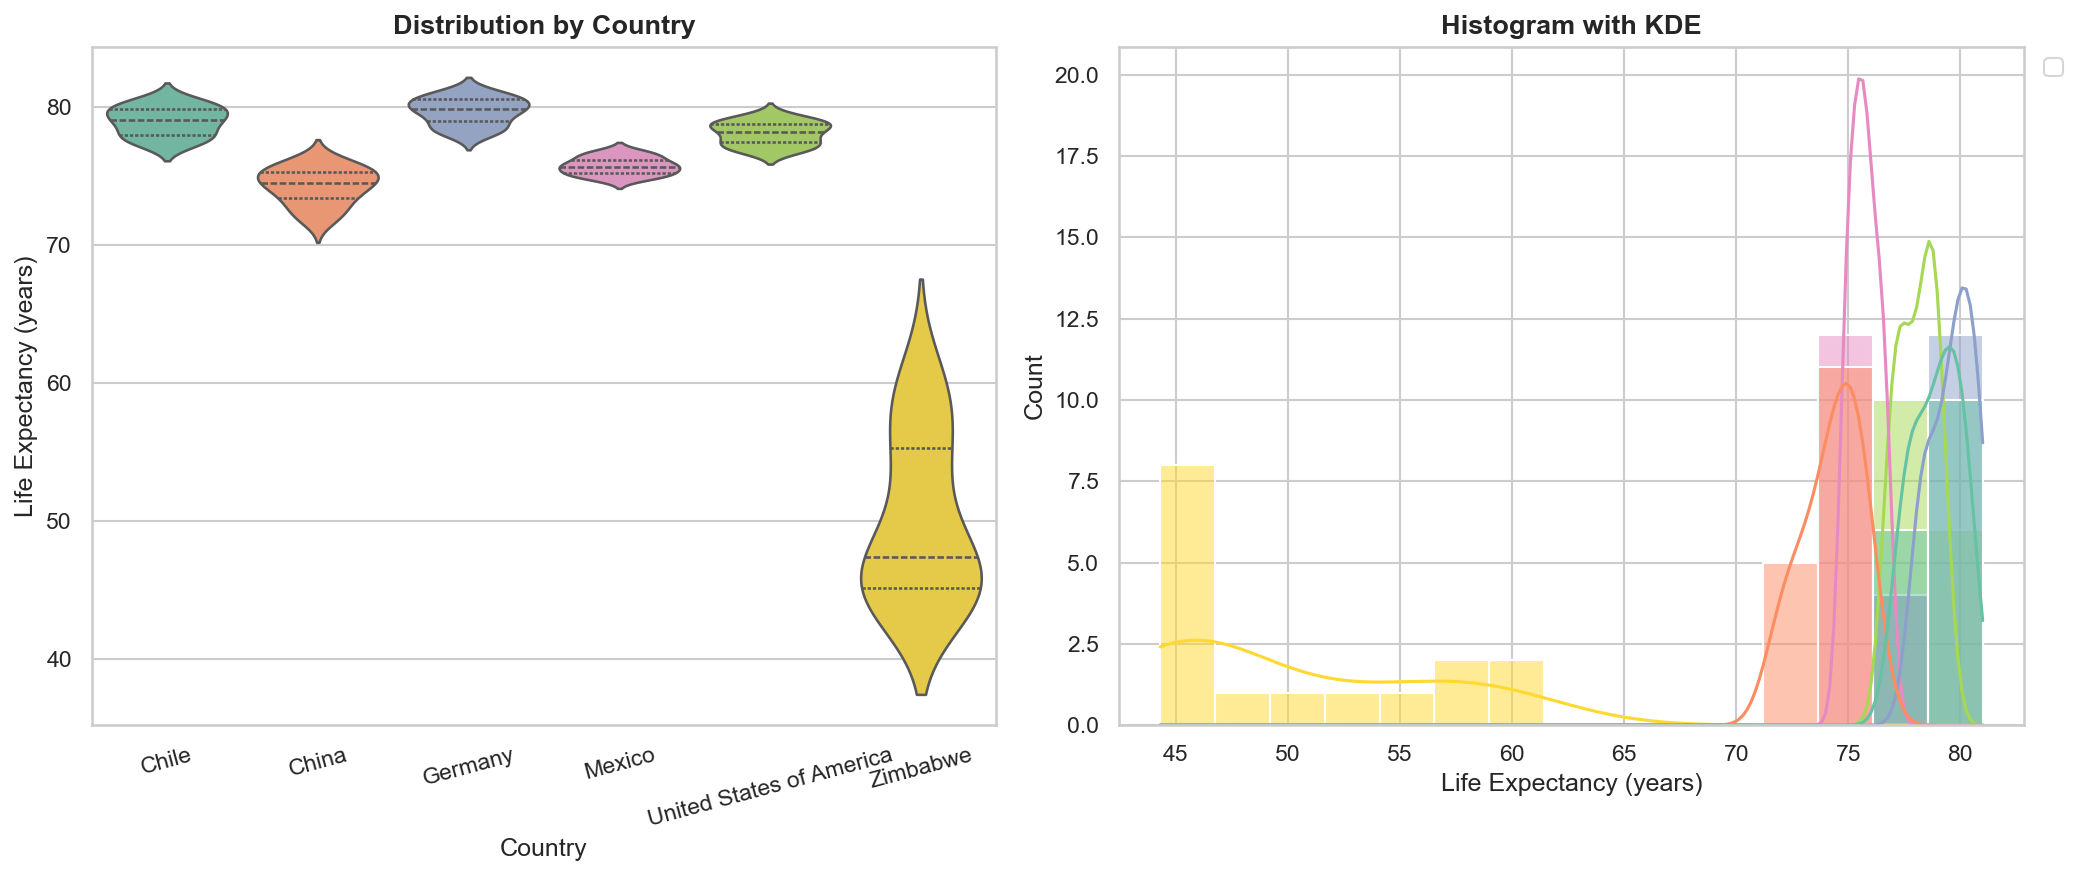

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin plot
sns.violinplot(data=df, x='Country', y='life_expectancy',
               palette='Set2', inner='quartile', ax=axes[0])
axes[0].set_title('Distribution by Country', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Life Expectancy (years)')
axes[0].tick_params(axis='x', rotation=15)

# Histogram
sns.histplot(data=df, x='life_expectancy', hue='Country',
             bins=15, kde=True, ax=axes[1])
axes[1].set_title('Histogram with KDE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('Count')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('images/life_expectancy_distribution.png', bbox_inches='tight')
plt.show()

### 4.6 Correlation Heatmap

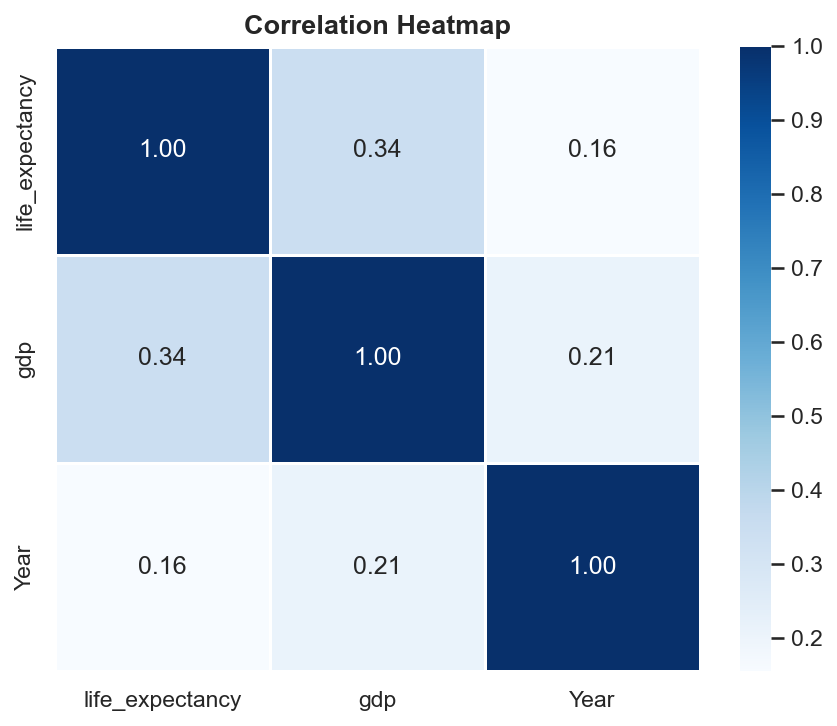

In [15]:
corr = df[['life_expectancy', 'gdp', 'Year']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()